In [57]:
# ============================================================
# N5 — MULTICRITERIA ANALYSIS - TerriZoom
# ============================================================
# This notebook performs:
# 1. Selection of a commune-level analytical subset from the unified table built in N4
# 2. Construction of a minimal multi-criteria framework for territorial comparison
# 3. Definition of criteria, directions of preference, and weighting assumptions
# 4. Calculation of commune-level rankings using multi-criteria decision methods
#    (starting with TOPSIS, and optionally extending to ELECTRE)
# 5. Interpretation of results in terms of differentiated territorial profiles
#
# The aim is not to produce a definitive ranking of communes, but to demonstrate a rigorous and transparent multi-criteria approach
# based on heterogeneous public data aggregated at commune level.

In [58]:
# ============================================================
# METHODOLOGY
# ============================================================
# The analysis is conducted at commune level, using the unified table prepared in N4.
# Only variables considered sufficiently robust, interpretable, and relevant for a first multi-criteria comparison are retained.
#
# Several methodological principles guide this notebook:
#
# 1. One analytical observation per commune
#    All selected indicators are expressed at commune level, after prior aggregation of income, crime, and air pollution data.
#
# 2. Limited and reasoned selection of criteria
#    The objective is not to include all available variables, but to retain a coherent subset covering several dimensions of territorial conditions
#    (for example: socio-economic situation, security, and environment).
#
# 3. Explicit direction of preference
#    For each criterion, the analysis specifies whether higher values are considered better (benefit criterion) or worse (cost criterion).
#
# 4. Control of redundancy
#    Highly correlated or conceptually overlapping variables should not be overrepresented, in order to avoid giving excessive weight to a single underlying dimension.
#
# 5. Standardization before comparison
#    Because the selected indicators are expressed in different units and scales, they must be normalized before any multi-criteria scoring or ranking procedure.
#
# 6. Transparent weighting assumptions
#    A first scenario may rely on equal weights, while alternative weighting schemes can be tested to assess the robustness of results.
#
# 7. Exploratory interpretation
#    The rankings produced in this notebook should be interpreted as analytical outputs of a chosen methodological framework, not as absolute or definitive judgements on communes.

In [59]:
#=====================================================
# Install libraries
#=====================================================

In [60]:
#!pip install pandas requests duckdb openpyxl matplotlib seaborn numpy dotenv

In [61]:
#=====================================================
# Import libraries
#=====================================================

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
#to draw graphs directly in notebook

In [63]:
# ========================================================================
# I — Load dataset for multicriteria analysis
# ========================================================================

In [64]:
# Open source file : terrizoom_communes.csv file

In [65]:
terrizoom_communes_subset = pd.read_csv(
    "terrizoom_communes.csv",
    sep=",",
    dtype={"insee_commune_id": str}
)
terrizoom_communes_subset["insee_commune_id"] = (
    terrizoom_communes_subset["insee_commune_id"]
    .str.zfill(5)
)
terrizoom_communes_subset.head()

,insee_commune_id,commune_name,population_total,density_class,density_label,count_agriculture_per_1000,count_industry_per_1000,count_construction_per_1000,count_commercial_services_per_1000,count_public_services_per_1000,...,no2_level_share_ge4,o3_level_share_ge4,pm10_level_share_ge4,pm25_level_share_ge4,so2_level_share_ge4,no2_level_share_ge5,o3_level_share_ge5,pm10_level_share_ge5,pm25_level_share_ge5,so2_level_share_ge5
0,01004,Ambérieu-en-Bugey,16339.0,2.0,Urbain intermédiaire,0.122407,2.019707,3.488586,25.154538,5.447090,...,0.0,0.038889,0.002778,0.016667,0.0,0.0,0.0,0.0,0.0,0.0
1,01033,Valserhône,17031.0,2.0,Urbain intermédiaire,0.234866,2.289942,5.578064,19.258998,3.464271,...,0.0,0.058333,0.005556,0.002778,0.0,0.0,0.0,0.0,0.0,0.0
2,01034,Belley,9695.0,2.0,Urbain intermédiaire,0.412584,4.228984,4.744714,26.611655,5.776173,...,0.0,0.038889,0.002778,0.025000,0.0,0.0,0.0,0.0,0.0,0.0
3,01053,Bourg-en-Bresse,43961.0,2.0,Urbain intermédiaire,0.113737,2.183754,2.365733,34.507859,6.915220,...,0.0,0.038889,0.002778,0.025000,0.0,0.0,0.0,0.0,0.0,0.0
4,01143,Divonne-les-Bains,10683.0,2.0,Urbain intermédiaire,0.280820,0.748853,0.842460,18.253300,3.089020,...,0.0,0.061111,0.005556,0.019444,0.0,0.0,0.0,0.0,0.0,0.0


In [66]:
# ============================================================
# Quick readiness checks for multicriteria analysis
# ============================================================
terrizoom_communes_subset.shape

(364, 61)

In [67]:
# NULL values
terrizoom_communes_subset.isna().sum().sort_values(ascending=False).head(20)

usage_de_stupefiants_per_1000                       13
vols_de_vehicule_per_1000                            9
vols_dans_les_vehicules_per_1000                     5
violences_physiques_hors_cadre_familial_per_1000     5
part_prestations_sociales_pct_std                    1
revenu_median_eur_std                                1
taux_bas_revenus_pct_std                             1
violences_physiques_intrafamiliales_per_1000         1
count_construction_per_1000                          0
count_agriculture_per_1000                           0
count_industry_per_1000                              0
commune_name                                         0
insee_commune_id                                     0
revenu_q1_eur                                        0
n_iris                                               0
total_count_per_1000                                 0
revenu_median_eur                                    0
taux_bas_revenus_pct                                 0
revenu_q3_

In [68]:
# Unique values
terrizoom_communes_subset.nunique().sort_values(ascending=False).head(50)

insee_commune_id                                           364
commune_name                                               364
total_count_per_1000                                       364
count_construction_per_1000                                364
count_industry_per_1000                                    364
count_commercial_services_per_1000                         363
count_public_services_per_1000                             362
population_total                                           359
revenu_median_eur_std                                      354
revenu_d9_eur                                              342
revenu_median_eur                                          337
revenu_q3_eur                                              336
part_revenus_activite_pct                                  335
revenu_q1_eur                                              333
part_prestations_sociales_pct_std                          333
cambriolages_de_logement_per_1000                      

In [69]:
# CONCLUSION
# The commune-level dataset is sufficiently mature to support a first minimal multi-criteria analysis.
# Its main strengths are:
# - one analytical observation per commune,
# - generally low levels of missing data,
# - and a coherent combination of socio-economic, security, and environmental indicators.
#
# However, the dataset should not be used as-is for TOPSIS with all available variables.
# Several indicators are either weakly discriminant, highly redundant, or affected by a small number of missing values.
#
# For a minimal and robust TOPSIS subset, the first approach is therefore:
# - to retain a limited subset of clearly interpretable criteria,
# - to avoid over-representing the same underlying dimension,
# - and to focus on a balanced combination of income, social vulnerability, crime, and pollution indicators.

In [70]:
# ========================================================================
# II — TOPSIS analysis
# ========================================================================

In [71]:
# ============================================================
# TOPSIS function
# ============================================================

def topsis(X: pd.DataFrame, weights: np.ndarray, impacts: np.ndarray):
    """
    TOPSIS implementation.

    Parameters
    ----------
    X : Criteria-only matrix
    weights : Normalized weights
    impacts : +1 for benefit criteria, -1 for cost criteria

    Returns
    -------
    result : TOPSIS scores and ranks
    X_norm : Normalized matrix
    X_weighted : Weighted normalized matrix
    ideal_best : Ideal best solution
    ideal_worst : Ideal worst solution
    """
    X = X.astype(float).copy()

    # 1. Vector normalization - brings all criteria onto a comparable scale
    # a. Compute the Euclidean norm of each column, i.e. the overall magnitude of each criterion
    norm = np.sqrt((X ** 2).sum(axis=0))

    # b. Divide each value by the Euclidean norm of its column to normalize the decision matrix
    X_norm = X / norm

    # 2. Weighting - we than apply agreed weight for each criteria
    X_weighted = X_norm * weights

    # 3. Ideal best / ideal worst = min or max of each column depending on wether the criteria should be maximized or minimized
    ideal_best = pd.Series(index=X.columns, dtype=float)
    ideal_worst = pd.Series(index=X.columns, dtype=float)

    for i, col in enumerate(X.columns):
        if impacts[i] == 1:
            ideal_best[col] = X_weighted[col].max()
            ideal_worst[col] = X_weighted[col].min()
        else:
            ideal_best[col] = X_weighted[col].min()
            ideal_worst[col] = X_weighted[col].max()

    # 4. Distances to ideal best / worst : Compute the Euclidean distances to the ideal and worst solutions:
    # - dist_best measures how far each commune is from the ideal best profile
    # - dist_worst measures how far each commune is from the ideal worst profile
    dist_best = np.sqrt(((X_weighted - ideal_best) ** 2).sum(axis=1))
    dist_worst = np.sqrt(((X_weighted - ideal_worst) ** 2).sum(axis=1))

    # 5. Closeness coefficient
    # If a commune is very close to the ideal solution and far from the worst one, its score increases.
    # If it is far from the ideal solution and close to the worst one, its score decreases.
    # Score near 1 = the best - score near 0 = the worst
    score = dist_worst / (dist_best + dist_worst)

    result = pd.DataFrame(index=X.index)
    result["topsis_score"] = score
    result["topsis_rank"] = result["topsis_score"].rank(ascending=False, method="dense").astype(int)

    result = result.sort_values("topsis_score", ascending=False)

    return result, X_norm, X_weighted, ideal_best, ideal_worst

In [72]:
# ============================================================
# TOPSIS criteria selection
# ============================================================

In [73]:
# CHOSEN TOPSIS SUBSET
#
# The selected TOPSIS subset combines four dimensions:
#
# TERRITORY DYNAMISM
# - count_commercial_services_per_1000 → to be maximized
# - count_public_services_per_1000 → to be maximized
#
# LEVEL OF LIFE : 
# - revenu_median_eur → to be maximized
# - taux_bas_revenus_pct → to be minimized
# - part_prestations_sociales_pct → to be minimized
# 
# SECURITY : 
# - cambriolages_de_logement_per_1000 → to be minimized
# - violences_physiques_intrafamiliales_per_1000 → to be minimized
# - usage_de_stupefiants_per_1000 → to be minimized
#
# POLLUTION :
# o3_level_share_ge4 → to be minimized
# pm25_level_share_ge4 → to be minimized

In [74]:
criteria = [
    "count_commercial_services_per_1000",
    "count_public_services_per_1000",
    "revenu_median_eur",
    "taux_bas_revenus_pct",
    "part_prestations_sociales_pct",
    "cambriolages_de_logement_per_1000",
    "violences_physiques_intrafamiliales_per_1000",
    "usage_de_stupefiants_per_1000",
    "o3_level_share_ge4",
    "pm25_level_share_ge4"
]

# +1 = benefit criterion (higher is better)
# -1 = cost criterion (lower is better)
impacts = np.array([
    +1,  # count_commercial_services_per_1000
    +1,  # count_public_services_per_1000
    +1,  # revenu_median_eur
    -1,  # taux_bas_revenus_pct
    -1,  # part_prestations_sociales_pct
    -1,  # cambriolages_de_logement_per_1000
    -1,  # violences_physiques_intrafamiliales_per_1000
    -1,  # usage_de_stupefiants_per_1000
    -1,  # o3_level_share_ge4
    -1   # pm25_level_share_ge4
], dtype=int)

In [75]:
# Remaining missing values are imputed using the median in order to preserve the full analytical sample.

In [76]:
decision_matrix = terrizoom_communes_subset[
    ["insee_commune_id", "commune_name"] + criteria
].copy()

# Median imputation for remaining missing values
for col in criteria:
    decision_matrix[col] = decision_matrix[col].fillna(decision_matrix[col].median())

decision_matrix.head()

,insee_commune_id,commune_name,count_commercial_services_per_1000,count_public_services_per_1000,revenu_median_eur,taux_bas_revenus_pct,part_prestations_sociales_pct,cambriolages_de_logement_per_1000,violences_physiques_intrafamiliales_per_1000,usage_de_stupefiants_per_1000,o3_level_share_ge4,pm25_level_share_ge4
0,01004,Ambérieu-en-Bugey,25.154538,5.447090,20525.0,17.75,7.85,7.16,3.51,2.85,0.038889,0.016667
1,01033,Valserhône,19.258998,3.464271,23210.0,18.17,4.80,6.25,3.14,4.66,0.058333,0.002778
2,01034,Belley,26.611655,5.776173,20930.0,19.00,7.20,4.09,2.33,2.22,0.038889,0.025000
3,01053,Bourg-en-Bresse,34.507859,6.915220,21185.0,23.67,9.24,4.51,2.92,9.50,0.038889,0.025000
4,01143,Divonne-les-Bains,18.253300,3.089020,45240.0,8.00,0.90,10.56,1.64,1.20,0.061111,0.019444


In [77]:
decision_matrix.isna().sum().sort_values(ascending=False).head(20)

insee_commune_id                                0
commune_name                                    0
count_commercial_services_per_1000              0
count_public_services_per_1000                  0
revenu_median_eur                               0
taux_bas_revenus_pct                            0
part_prestations_sociales_pct                   0
cambriolages_de_logement_per_1000               0
violences_physiques_intrafamiliales_per_1000    0
usage_de_stupefiants_per_1000                   0
o3_level_share_ge4                              0
pm25_level_share_ge4                            0
dtype: int64

In [78]:
# --------------------------------------------------------
# FIRST SCENARIO: equal weights over all criteria
# --------------------------------------------------------

In [79]:
weights = np.ones(len(criteria), dtype=float)
weights1 = weights / weights.sum()
weights1

array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

In [80]:
# ============================================================
# Run TOPSIS - FIRST RUN
# ============================================================

X = decision_matrix[criteria]

topsis_result1, X_norm1, X_weighted1, ideal_best1, ideal_worst1 = topsis(
    X=X,
    weights=weights1,
    impacts=impacts
)

topsis_output1 = pd.concat(
    [decision_matrix[["insee_commune_id", "commune_name"]], topsis_result1],
    axis=1
).sort_values("topsis_score", ascending=False)

topsis_output1.head(20)

,insee_commune_id,commune_name,topsis_score,topsis_rank
334,83119,Saint-Tropez,0.715580,1
56,06152,Valbonne,0.622861,2
285,74056,Chamonix-Mont-Blanc,0.591970,3
211,63014,Aubière,0.586296,4
36,06018,Biot,0.585170,5
321,83070,Lavandou,0.584999,6
273,73054,Bourg-Saint-Maurice,0.582466,7
89,13042,Gémenos,0.577285,8
331,83115,Sainte-Maxime,0.575468,9
83,13032,Éguilles,0.573099,10


In [81]:
# Bottom 20 communes
topsis_output1.tail(20)

,insee_commune_id,commune_name,topsis_score,topsis_rank
102,13077,Port-de-Bouc,0.472526,345
346,84019,Bollène,0.472077,346
348,84035,Cavaillon,0.472035,347
344,84007,Avignon,0.471744,348
289,74133,Gaillard,0.471642,349
257,69264,Villefranche-sur-Saône,0.468710,350
190,42186,Rive-de-Gier,0.468675,351
95,13055,Marseille,0.467008,352
267,69286,Rillieux-la-Pape,0.463430,353
250,69199,Saint-Fons,0.461548,354


In [82]:
# ============================================================
# Inspect TOPSIS ingredients
# ============================================================
display(pd.DataFrame({
    "criterion": criteria,
    "weight": weights1,
    "impact": impacts
}))

display(ideal_best1.to_frame("ideal_best"))
display(ideal_worst1.to_frame("ideal_worst"))

,criterion,weight,impact
0,count_commercial_services_per_1000,0.1,1
1,count_public_services_per_1000,0.1,1
2,revenu_median_eur,0.1,1
3,taux_bas_revenus_pct,0.1,-1
4,part_prestations_sociales_pct,0.1,-1
5,cambriolages_de_logement_per_1000,0.1,-1
6,violences_physiques_intrafamiliales_per_1000,0.1,-1
7,usage_de_stupefiants_per_1000,0.1,-1
8,o3_level_share_ge4,0.1,-1
9,pm25_level_share_ge4,0.1,-1


,ideal_best
count_commercial_services_per_1000,0.039015
count_public_services_per_1000,0.015479
revenu_median_eur,0.009731
taux_bas_revenus_pct,0.001147
part_prestations_sociales_pct,0.000734
cambriolages_de_logement_per_1000,0.000714
violences_physiques_intrafamiliales_per_1000,0.001184
usage_de_stupefiants_per_1000,0.000572
o3_level_share_ge4,0.000646
pm25_level_share_ge4,0.000000


,ideal_worst
count_commercial_services_per_1000,0.001221
count_public_services_per_1000,0.001812
revenu_median_eur,0.003362
taux_bas_revenus_pct,0.012454
part_prestations_sociales_pct,0.015021
cambriolages_de_logement_per_1000,0.012283
violences_physiques_intrafamiliales_per_1000,0.009168
usage_de_stupefiants_per_1000,0.037233
o3_level_share_ge4,0.009265
pm25_level_share_ge4,0.021885


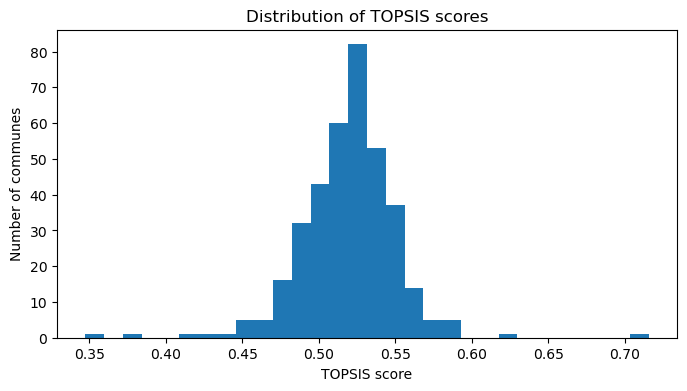

In [83]:
# ============================================================
# Distribution of TOPSIS scores
# ============================================================
plt.figure(figsize=(8, 4))
plt.hist(topsis_output1["topsis_score"], bins=30)
plt.title("Distribution of TOPSIS scores")
plt.xlabel("TOPSIS score")
plt.ylabel("Number of communes")
plt.show()

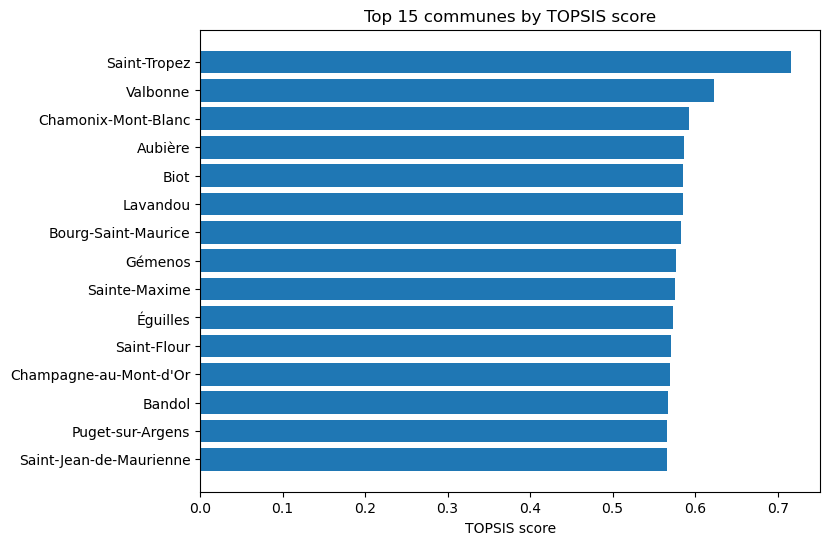

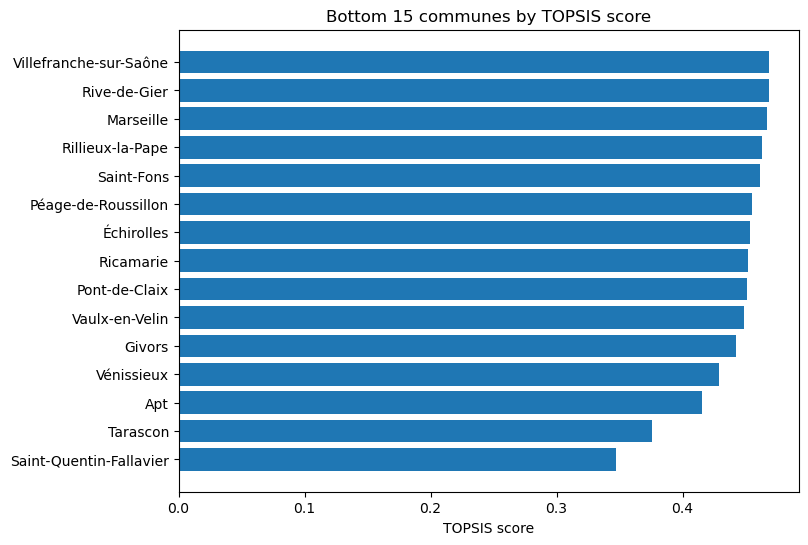

In [84]:
# ============================================================
# Top and bottom communes
# ============================================================
top15 = topsis_output1.head(15).sort_values("topsis_score")
bottom15 = topsis_output1.tail(15).sort_values("topsis_score")

plt.figure(figsize=(8, 6))
plt.barh(top15["commune_name"], top15["topsis_score"])
plt.title("Top 15 communes by TOPSIS score")
plt.xlabel("TOPSIS score")
plt.show()

plt.figure(figsize=(8, 6))
plt.barh(bottom15["commune_name"], bottom15["topsis_score"])
plt.title("Bottom 15 communes by TOPSIS score")
plt.xlabel("TOPSIS score")
plt.show()

In [85]:
# ============================================================
# Reattach selected criteria for interpretation
# ============================================================
top_bottom_ids1 = pd.concat([
    topsis_output1.head(10),
    topsis_output1.tail(10)
])["insee_commune_id"]

topsis_interpretation1 = terrizoom_communes_subset.loc[
    terrizoom_communes_subset["insee_commune_id"].isin(top_bottom_ids1),
    ["insee_commune_id", "commune_name"] + criteria
].merge(
    topsis_output1[["insee_commune_id", "topsis_score", "topsis_rank"]],
    on="insee_commune_id",
    how="left"
).sort_values("topsis_score", ascending=False)

topsis_interpretation1.round(3)

,insee_commune_id,commune_name,count_commercial_services_per_1000,count_public_services_per_1000,revenu_median_eur,taux_bas_revenus_pct,part_prestations_sociales_pct,cambriolages_de_logement_per_1000,violences_physiques_intrafamiliales_per_1000,usage_de_stupefiants_per_1000,o3_level_share_ge4,pm25_level_share_ge4,topsis_score,topsis_rank
18,83119,Saint-Tropez,237.599,6.303,26305.0,14.50,1.35,7.48,4.54,15.14,0.069,0.003,0.716,1
1,06152,Valbonne,81.853,8.840,31185.0,9.50,3.12,5.96,1.56,4.77,0.086,0.003,0.623,2
15,74056,Chamonix-Mont-Blanc,87.997,5.763,24715.0,14.75,2.22,1.68,1.86,10.54,0.025,0.008,0.592,3
10,63014,Aubière,57.283,5.370,24320.0,11.00,4.58,10.27,1.38,0.90,0.028,0.019,0.586,4
0,06018,Biot,53.020,4.887,31410.0,8.33,2.00,8.18,1.44,1.91,0.083,0.003,0.585,5
16,83070,Lavandou,75.685,4.470,22870.0,17.50,3.95,2.06,3.12,6.33,0.069,0.000,0.585,6
14,73054,Bourg-Saint-Maurice,78.752,6.640,23240.0,14.00,3.00,1.36,2.83,9.76,0.028,0.008,0.582,7
3,13042,Gémenos,58.999,4.172,28820.0,7.00,2.50,12.78,1.89,2.34,0.105,0.006,0.577,8
17,83115,Sainte-Maxime,58.345,4.208,22820.0,15.60,3.34,4.50,2.78,3.52,0.075,0.003,0.575,9
2,13032,Éguilles,46.170,5.439,33400.0,6.33,2.00,14.34,1.91,0.60,0.100,0.008,0.573,10


In [86]:
# OBSERVATION:
# This first TOPSIS ranking produces a strong contrast between communes combining relatively favorable socio-economic conditions and territorial dynamism,
# and communes accumulating weaker outcomes across several dimensions.
#
# At the top of the ranking, Saint-Tropez stands out very clearly, driven in particular by an exceptionally high level of commercial services per 1,000 inhabitants.
# Other highly ranked communes such as Valbonne, Chamonix-Mont-Blanc, Biot, and Bourg-Saint-Maurice also combine relatively strong local dynamism, moderate social vulnerability,
# and comparatively limited pollution or security pressures within the selected framework.
#
# At the bottom of the ranking, Saint-Quentin-Fallavier appears as the most penalized commune, mainly because of a very high value for drug use and weaker overall balance across the chosen criteria.
# Tarascon, Apt, Vénissieux, Givors, and Vaulx-en-Velin also rank low, reflecting a combination of lower median income, higher social vulnerability, and less favorable security or pollution indicators.
#
# The ranking is therefore not driven by a single variable alone, but by the cumulative effect of several dimensions: territorial dynamism, standard of living, security, and pollution.
# At the same time, some criteria appear especially structuring in the final ordering, notably commercial services density, median income, social vulnerability,
# and a few high-contrast security indicators such as drug use.
#
# This result should be interpreted as an exploratory multicriteria ranking under an equal-weight assumption. It reflects the analytical framework chosen here, not an absolute judgement on the communes themselves.

In [87]:
# Current weights correspond to:
# - 20 % territorial dynamism
# - 30 % level of life
# - 30 % security
# - 20 % pollution

In [88]:
# SECOND SCENARIO - Weights balanced by dimension

In [89]:
criteria = [
    "count_commercial_services_per_1000",
    "count_public_services_per_1000",
    "revenu_median_eur",
    "taux_bas_revenus_pct",
    "part_prestations_sociales_pct",
    "cambriolages_de_logement_per_1000",
    "violences_physiques_intrafamiliales_per_1000",
    "usage_de_stupefiants_per_1000",
    "o3_level_share_ge4",
    "pm25_level_share_ge4"
]

weights2 = np.array([
    0.125, 0.125,      # dynamism = 25%
    0.0833, 0.0833, 0.0834,   # level of life = 25%
    0.0833, 0.0833, 0.0834,   # security = 25%
    0.125, 0.125       # pollution = 25%
])

weights2

array([0.125 , 0.125 , 0.0833, 0.0833, 0.0834, 0.0833, 0.0833, 0.0834,
       0.125 , 0.125 ])

In [90]:
# ============================================================
# Run TOPSIS - Second RUN
# ============================================================

X = decision_matrix[criteria]

topsis_result2, X_norm2, X_weighted2, ideal_best2, ideal_worst2 = topsis(
    X=X,
    weights=weights2,
    impacts=impacts
)

topsis_output2 = pd.concat(
    [decision_matrix[["insee_commune_id", "commune_name"]], topsis_result2],
    axis=1
).sort_values("topsis_score", ascending=False)

topsis_output2.head(20)

,insee_commune_id,commune_name,topsis_score,topsis_rank
334,83119,Saint-Tropez,0.754547,1
56,06152,Valbonne,0.570904,2
285,74056,Chamonix-Mont-Blanc,0.553542,3
273,73054,Bourg-Saint-Maurice,0.541422,4
321,83070,Lavandou,0.536621,5
211,63014,Aubière,0.522553,6
36,06018,Biot,0.520859,7
331,83115,Sainte-Maxime,0.516862,8
89,13042,Gémenos,0.515780,9
124,15187,Saint-Flour,0.515336,10


In [91]:
topsis_output2.tail(20)

,insee_commune_id,commune_name,topsis_score,topsis_rank
190,42186,Rive-de-Gier,0.406944,345
164,38425,Saint-Maurice-l'Exil,0.406674,346
343,84003,Apt,0.406266,347
357,84092,Pontet,0.405569,348
267,69286,Rillieux-la-Pape,0.403735,349
188,42183,Ricamarie,0.403326,350
162,38421,Saint-Martin-d'Hères,0.401391,351
145,38158,Eybens,0.401384,352
242,69096,Grigny-sur-Rhône,0.396610,353
289,74133,Gaillard,0.396458,354


In [92]:
display(pd.DataFrame({
    "criterion": criteria,
    "weight": weights2,
    "impact": impacts
}))

display(ideal_best2.to_frame("ideal_best"))
display(ideal_worst2.to_frame("ideal_worst"))

,criterion,weight,impact
0,count_commercial_services_per_1000,0.1250,1
1,count_public_services_per_1000,0.1250,1
2,revenu_median_eur,0.0833,1
3,taux_bas_revenus_pct,0.0833,-1
4,part_prestations_sociales_pct,0.0834,-1
5,cambriolages_de_logement_per_1000,0.0833,-1
6,violences_physiques_intrafamiliales_per_1000,0.0833,-1
7,usage_de_stupefiants_per_1000,0.0834,-1
8,o3_level_share_ge4,0.1250,-1
9,pm25_level_share_ge4,0.1250,-1


,ideal_best
count_commercial_services_per_1000,0.048769
count_public_services_per_1000,0.019349
revenu_median_eur,0.008106
taux_bas_revenus_pct,0.000955
part_prestations_sociales_pct,0.000612
cambriolages_de_logement_per_1000,0.000595
violences_physiques_intrafamiliales_per_1000,0.000986
usage_de_stupefiants_per_1000,0.000477
o3_level_share_ge4,0.000808
pm25_level_share_ge4,0.000000


,ideal_worst
count_commercial_services_per_1000,0.001526
count_public_services_per_1000,0.002264
revenu_median_eur,0.002800
taux_bas_revenus_pct,0.010374
part_prestations_sociales_pct,0.012528
cambriolages_de_logement_per_1000,0.010232
violences_physiques_intrafamiliales_per_1000,0.007637
usage_de_stupefiants_per_1000,0.031052
o3_level_share_ge4,0.011582
pm25_level_share_ge4,0.027356


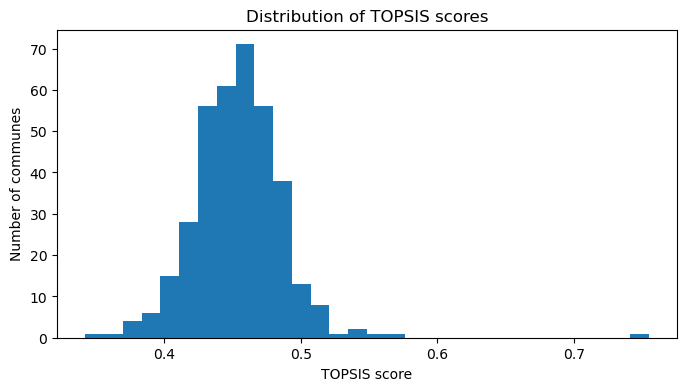

In [93]:
plt.figure(figsize=(8, 4))
plt.hist(topsis_output2["topsis_score"], bins=30)
plt.title("Distribution of TOPSIS scores")
plt.xlabel("TOPSIS score")
plt.ylabel("Number of communes")
plt.show()

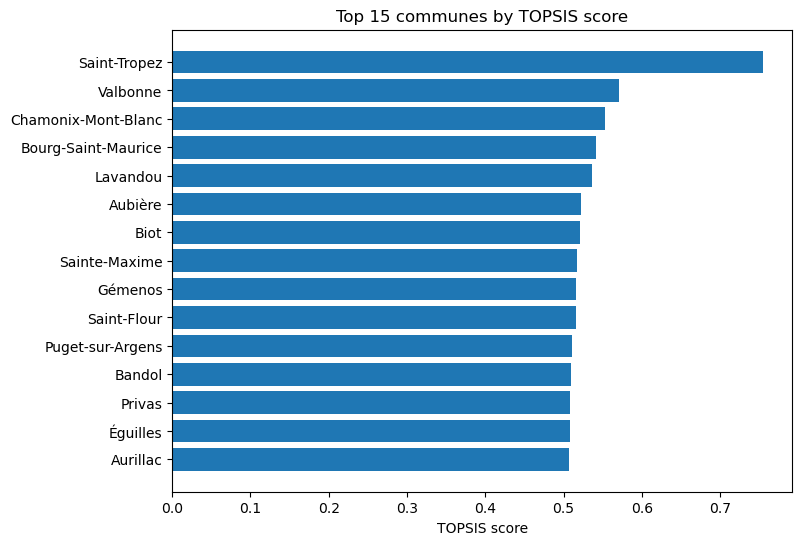

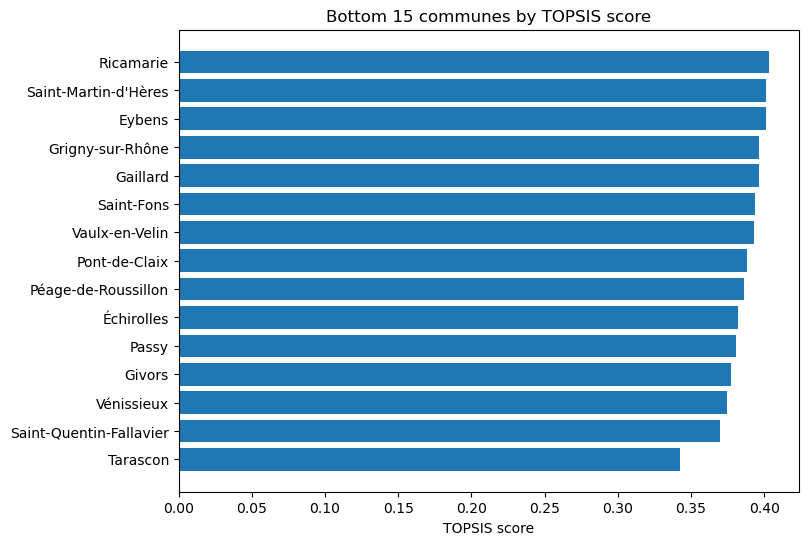

In [94]:
top15 = topsis_output2.head(15).sort_values("topsis_score")
bottom15 = topsis_output2.tail(15).sort_values("topsis_score")

plt.figure(figsize=(8, 6))
plt.barh(top15["commune_name"], top15["topsis_score"])
plt.title("Top 15 communes by TOPSIS score")
plt.xlabel("TOPSIS score")
plt.show()

plt.figure(figsize=(8, 6))
plt.barh(bottom15["commune_name"], bottom15["topsis_score"])
plt.title("Bottom 15 communes by TOPSIS score")
plt.xlabel("TOPSIS score")
plt.show()

In [95]:
top_bottom_ids2 = pd.concat([
    topsis_output2.head(10),
    topsis_output2.tail(10)
])["insee_commune_id"]

topsis_interpretation2 = terrizoom_communes_subset.loc[
    terrizoom_communes_subset["insee_commune_id"].isin(top_bottom_ids2),
    ["insee_commune_id", "commune_name"] + criteria
].merge(
    topsis_output2[["insee_commune_id", "topsis_score", "topsis_rank"]],
    on="insee_commune_id",
    how="left"
).sort_values("topsis_score", ascending=False)

topsis_interpretation2.round(3)

,insee_commune_id,commune_name,count_commercial_services_per_1000,count_public_services_per_1000,revenu_median_eur,taux_bas_revenus_pct,part_prestations_sociales_pct,cambriolages_de_logement_per_1000,violences_physiques_intrafamiliales_per_1000,usage_de_stupefiants_per_1000,o3_level_share_ge4,pm25_level_share_ge4,topsis_score,topsis_rank
19,83119,Saint-Tropez,237.599,6.303,26305.0,14.50,1.35,7.48,4.54,15.14,0.069,0.003,0.755,1
1,06152,Valbonne,81.853,8.840,31185.0,9.50,3.12,5.96,1.56,4.77,0.086,0.003,0.571,2
15,74056,Chamonix-Mont-Blanc,87.997,5.763,24715.0,14.75,2.22,1.68,1.86,10.54,0.025,0.008,0.554,3
14,73054,Bourg-Saint-Maurice,78.752,6.640,23240.0,14.00,3.00,1.36,2.83,9.76,0.028,0.008,0.541,4
17,83070,Lavandou,75.685,4.470,22870.0,17.50,3.95,2.06,3.12,6.33,0.069,0.000,0.537,5
9,63014,Aubière,57.283,5.370,24320.0,11.00,4.58,10.27,1.38,0.90,0.028,0.019,0.523,6
0,06018,Biot,53.020,4.887,31410.0,8.33,2.00,8.18,1.44,1.91,0.083,0.003,0.521,7
18,83115,Sainte-Maxime,58.345,4.208,22820.0,15.60,3.34,4.50,2.78,3.52,0.075,0.003,0.517,8
2,13042,Gémenos,58.999,4.172,28820.0,7.00,2.50,12.78,1.89,2.34,0.105,0.006,0.516,9
4,15187,Saint-Flour,38.086,10.360,21195.0,14.50,6.10,2.96,2.84,2.96,0.033,0.003,0.515,10


In [96]:
# OBSERVATION:
# Under the second weighting scenario, the ranking remains partly stable at the top, but becomes less dominated by a single highly dynamic profile.
#
# Saint-Tropez still ranks first, which suggests that its position is not only driven by commercial-service density, but also supported by a broader combination of favorable indicators.
# Valbonne, Chamonix-Mont-Blanc, Bourg-Saint-Maurice, Lavandou, Biot, and Sainte-Maxime also remain in the upper part of the ranking, which points to a relatively robust profile
# across the selected dimensions.
#
# At the same time, some changes appear compared with the first scenario.
# Saint-Flour enters the top 10, while Aubière moves slightly downward. This suggests that the revised weighting reduces the influence of the most dominant criteria
# and gives more room to communes with a more balanced overall profile.
#
# At the bottom of the ranking, Tarascon now appears as the lowest-ranked commune, followed by Saint-Quentin-Fallavier, Vénissieux, Givors, Passy, Échirolles,
# Péage-de-Roussillon, Pont-de-Claix, Vaulx-en-Velin, and Saint-Fons.
# This lower end of the ranking remains strongly associated with a combination of higher social vulnerability, weaker income conditions, and less favorable security
# or pollution indicators.
#
# Overall, this second scenario confirms that the ranking is sensitive to weighting choices, but not unstable.
# The main top and bottom profiles remain broadly consistent, while some intermediate movements show that weighting assumptions do influence
# the final hierarchy and should therefore be made explicit.

In [97]:
# SCENARIO 1 & 2 COMPARISION :
#
# The first scenario produces a TOPSIS score distribution more clearly centered around 0.5, which suggests a more moderate and less polarized ranking.
# In this case, most communes remain positioned in an intermediate zone between the ideal and worst solutions.
#
# By contrast, the second scenario is less centered around 0.5 and therefore more discriminant.
# It increases the separation between communes with more favorable profiles (increased TOPSIS score) and those with less favorable ones,
# producing a more contrasted multicriteria hierarchy.
#
# In analytical terms, the first scenario can be read as a baseline, while the second scenario behaves more like a sensitivity test:
# it shows how the ranking changes when the weighting structure gives a different balance across the selected dimensions.

In [ ]:
# ========================================================================
# II — ELECTRE analysis
# ========================================================================
# Applied methodology
# -------------------
# ELECTRE III is used here as a complementary multicriteria method to compare communes on the basis of several heterogeneous indicators.
#
# Unlike TOPSIS, which ranks communes according to their distance to an ideal and a worst solution, ELECTRE III follows an outranking logic.
# It compares communes pairwise and evaluates whether one commune can reasonably be considered at least as good as another, while taking into account limited differences, clear preferences,
# and potentially strong disadvantages.
#
# The method relies on three thresholds defined for each criterion:
# - q: indifference threshold
# - p: preference threshold
# - v: veto threshold
#
# These thresholds make it possible to distinguish:
# - small differences that should not matter much,
# - larger differences that justify a preference,
# - and very large disadvantages that can weaken or block an outranking relation.
#
# In this notebook, ELECTRE III is applied in a simplified but rigorous way:
# 1. the same commune-level criteria as in TOPSIS are retained;
# 2. all criteria are transformed so that higher values always mean better performance;
# 3. q, p, and v thresholds are defined for each criterion;
# 4. partial concordance and discordance indices are computed pairwise;
# 5. these are combined into a credibility matrix;
# 6. the credibility matrix is then used to derive an exploratory outranking structure.
#
# The objective is not to produce a definitive final ordering of communes, but to provide a second multicriteria reading of the dataset,
# one that is more sensitive to thresholds and less purely compensatory than TOPSIS.

In [119]:
# ============================================================
# Partial concordance function
 """
 For one criterion, partial concordance measures the degree to which commune a can be considered at least as good as commune b.
 
 Reminder :
  - q: indifference threshold
  - p: preference threshold

 Since all criteria have already been transformed so that higher = better:
 - if a is only slightly worse than b (difference <= q), the difference is considered negligible -> full concordance = 1
 - if a is clearly worse than b (difference >= p), the criterion no longer supports the statement "a outranks b" -> concordance = 0
 - between q and p, concordance decreases progressively from 1 to 0
 """
# ============================================================
def partial_concordance(a, b, q, p):
    delta = b - a  # how much b is better than a

    if delta <= q:
        return 1.0
    elif delta >= p:
        return 0.0
    else:
        return (p - delta) / (p - q)

In [103]:
# ============================================================
# Partial discordance function
 """
 For one criterion, partial discordance measures the extent to which commune a is so much worse than commune b that this criterion
 should weaken the outranking relation.

 Reminder :
  - p: preference threshold
  - v: veto threshold

 Since all criteria have already been transformed so that higher = better:
 - if a is not much worse than b (difference <= p), there is no opposition -> discordance = 0
 - if a is much worse than b (difference >= v), this criterion fully opposes the outranking -> discordance = 1
 - between p and v, discordance increases progressively from 0 to 1
 """
# ============================================================
def partial_discordance(a, b, p, v):
    delta = b - a  # how much b is better than a

    if delta <= p:
        return 0.0
    elif delta >= v:
        return 1.0
    else:
        return (delta - p) / (v - p)

In [104]:
# ============================================================
# ELECTRE III matrices
 """
 This function computes the main pairwise comparison outputs used in ELECTRE III.

 For every ordered pair of communes (i, j):
 1. Partial concordance is computed for each criterion:
    it measures how much that criterion supports the statement "commune i outranks commune j".

 2. Partial discordance is computed for each criterion:
    it measures how much that criterion opposes the statement "commune i outranks commune j".

 3. Global concordance is then calculated as the weighted average of all partial concordance indices.
    It summarizes the overall support for "i outranks j".

 4. Credibility starts from global concordance, then is reduced when one or more criteria show discordance
    stronger than the global concordance level.
    This means that very unfavorable gaps on some criteria can weaken the outranking relation, even if the overall support is good.

 Outputs:
 - C_global: overall concordance matrix
 - partial_c: partial concordance values for each pair and criterion
 - partial_d: partial discordance values for each pair and criterion
 - credibility: final credibility matrix of the outranking relation
 """
# ============================================================

def electre_iii(X_benefit, weights, thresholds):
    n = X_benefit.shape[0]
    m = X_benefit.shape[1]
    values = X_benefit.to_numpy()

    C_global = np.zeros((n, n))
    credibility = np.zeros((n, n))

    partial_c = np.zeros((n, n, m))
    partial_d = np.zeros((n, n, m))

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            # Partial concordance / discordance for each criterion
            for k, col in enumerate(X_benefit.columns):
                a = values[i, k]
                b = values[j, k]
                q = thresholds.loc[col, "q"]
                p = thresholds.loc[col, "p"]
                v = thresholds.loc[col, "v"]

                partial_c[i, j, k] = partial_concordance(a, b, q, p)
                partial_d[i, j, k] = partial_discordance(a, b, p, v)

            # Global concordance = weighted average of partial concordance indices
            C_global[i, j] = np.sum(weights * partial_c[i, j, :]) / np.sum(weights)

            # Credibility = starts from global concordance and is penalized if some criteria oppose the outranking too strongly
            sigma = C_global[i, j]

            for k in range(m):
                dkj = partial_d[i, j, k]
                if dkj > C_global[i, j]:
                    sigma *= (1 - dkj) / (1 - C_global[i, j])

            credibility[i, j] = sigma

    return C_global, partial_c, partial_d, credibility

In [105]:
# ============================================================
# Prepare Matrix
# ============================================================

In [106]:
electre_matrix = decision_matrix[["insee_commune_id", "commune_name"] + criteria].copy()
X_raw = electre_matrix[criteria].astype(float).copy()
electre_matrix.head()

,insee_commune_id,commune_name,count_commercial_services_per_1000,count_public_services_per_1000,revenu_median_eur,taux_bas_revenus_pct,part_prestations_sociales_pct,cambriolages_de_logement_per_1000,violences_physiques_intrafamiliales_per_1000,usage_de_stupefiants_per_1000,o3_level_share_ge4,pm25_level_share_ge4
0,01004,Ambérieu-en-Bugey,25.154538,5.447090,20525.0,17.75,7.85,7.16,3.51,2.85,0.038889,0.016667
1,01033,Valserhône,19.258998,3.464271,23210.0,18.17,4.80,6.25,3.14,4.66,0.058333,0.002778
2,01034,Belley,26.611655,5.776173,20930.0,19.00,7.20,4.09,2.33,2.22,0.038889,0.025000
3,01053,Bourg-en-Bresse,34.507859,6.915220,21185.0,23.67,9.24,4.51,2.92,9.50,0.038889,0.025000
4,01143,Divonne-les-Bains,18.253300,3.089020,45240.0,8.00,0.90,10.56,1.64,1.20,0.061111,0.019444


In [107]:
X_raw .head()

,count_commercial_services_per_1000,count_public_services_per_1000,revenu_median_eur,taux_bas_revenus_pct,part_prestations_sociales_pct,cambriolages_de_logement_per_1000,violences_physiques_intrafamiliales_per_1000,usage_de_stupefiants_per_1000,o3_level_share_ge4,pm25_level_share_ge4
0,25.154538,5.447090,20525.0,17.75,7.85,7.16,3.51,2.85,0.038889,0.016667
1,19.258998,3.464271,23210.0,18.17,4.80,6.25,3.14,4.66,0.058333,0.002778
2,26.611655,5.776173,20930.0,19.00,7.20,4.09,2.33,2.22,0.038889,0.025000
3,34.507859,6.915220,21185.0,23.67,9.24,4.51,2.92,9.50,0.038889,0.025000
4,18.253300,3.089020,45240.0,8.00,0.90,10.56,1.64,1.20,0.061111,0.019444


In [108]:
# ============================================================
# Transform all criteria into benefit-oriented criteria
# ============================================================

X_benefit = X_raw.copy()

for i, col in enumerate(criteria):
    if impacts[i] == -1:
        X_benefit[col] = -X_benefit[col]

X_benefit.head()

,count_commercial_services_per_1000,count_public_services_per_1000,revenu_median_eur,taux_bas_revenus_pct,part_prestations_sociales_pct,cambriolages_de_logement_per_1000,violences_physiques_intrafamiliales_per_1000,usage_de_stupefiants_per_1000,o3_level_share_ge4,pm25_level_share_ge4
0,25.154538,5.447090,20525.0,-17.75,-7.85,-7.16,-3.51,-2.85,-0.038889,-0.016667
1,19.258998,3.464271,23210.0,-18.17,-4.80,-6.25,-3.14,-4.66,-0.058333,-0.002778
2,26.611655,5.776173,20930.0,-19.00,-7.20,-4.09,-2.33,-2.22,-0.038889,-0.025000
3,34.507859,6.915220,21185.0,-23.67,-9.24,-4.51,-2.92,-9.50,-0.038889,-0.025000
4,18.253300,3.089020,45240.0,-8.00,-0.90,-10.56,-1.64,-1.20,-0.061111,-0.019444


In [109]:
# ====================================================================================
# Define ELECTRE III thresholds - Can be modified in different ELECTRE SCENARIOS
# ====================================================================================

ranges = X_raw.max() - X_raw.min()

thresholds = pd.DataFrame(index=criteria)
thresholds["q"] = 0.05 * ranges
thresholds["p"] = 0.15 * ranges
thresholds["v"] = 0.30 * ranges

thresholds

,q,p,v
count_commercial_services_per_1000,11.508132,34.524397,69.048794
count_public_services_per_1000,0.597959,1.793876,3.587752
revenu_median_eur,1480.500000,4441.500000,8883.000000
taux_bas_revenus_pct,1.725000,5.175000,10.350000
part_prestations_sociales_pct,0.876000,2.628000,5.256000
cambriolages_de_logement_per_1000,0.963500,2.890500,5.781000
violences_physiques_intrafamiliales_per_1000,0.199000,0.597000,1.194000
usage_de_stupefiants_per_1000,1.761000,5.283000,10.566000
o3_level_share_ge4,0.005540,0.016620,0.033241
pm25_level_share_ge4,0.006944,0.020833,0.041667


In [110]:
# ====================================================================================
# ELECTRE III Execution
# ====================================================================================

In [111]:
C_global, partial_c, partial_d, credibility = electre_iii(
    X_benefit=X_benefit,
    weights=weights,
    thresholds=thresholds
)

In [112]:
# ============================================================
# Outranking relation from credibility matrix
# ============================================================

lambda_cut = 0.70

outranking = (credibility >= lambda_cut).astype(int)
np.fill_diagonal(outranking, 0)

In [122]:
# ============================================================
# Commune-level ELECTRE III summary
# ============================================================

electre_result = electre_matrix[["insee_commune_id", "commune_name"]].copy()

electre_result["outranks_count"] = outranking.sum(axis=1)
electre_result["outranked_by_count"] = outranking.sum(axis=0)

# --------------------------------------------------------------
# NET OUTRANKING SCORE
# The net outranking score is the balance between:
# - the number of communes a given commune outranks,
# - and the number of communes that outrank it.
#
# A high positive score means that the commune dominates many others while being dominated by relatively few.
# A low or negative score means the opposite.
# --------------------------------------------------------------
electre_result["net_outranking_score"] = (
    electre_result["outranks_count"] - electre_result["outranked_by_count"]
)
electre_result  = electre_result.merge(
    decision_matrix[["insee_commune_id"] + criteria],
    on=["insee_commune_id"],
    how="left"
)
electre_result = electre_result.sort_values(
    ["net_outranking_score", "outranks_count"],
    ascending=[False, False]
)

electre_result.head(20)

,insee_commune_id,commune_name,outranks_count,outranked_by_count,net_outranking_score,count_commercial_services_per_1000,count_public_services_per_1000,revenu_median_eur,taux_bas_revenus_pct,part_prestations_sociales_pct,cambriolages_de_logement_per_1000,violences_physiques_intrafamiliales_per_1000,usage_de_stupefiants_per_1000,o3_level_share_ge4,pm25_level_share_ge4
302,74280,Thônes,334,5,329,29.896014,3.899480,25480.0,6.50,3.00,2.69,0.98,2.49,0.047222,0.002778
285,74056,Chamonix-Mont-Blanc,322,1,321,87.997340,5.763050,24715.0,14.75,2.22,1.68,1.86,10.54,0.025000,0.008333
276,73179,Motte-Servolex,337,27,310,29.615082,5.106049,26230.0,8.00,3.30,6.70,1.54,1.29,0.027778,0.033333
216,63075,Chamalières,326,19,307,19.436292,4.762168,26790.0,9.25,3.10,8.15,1.00,0.55,0.033333,0.019444
206,43137,Monistrol-sur-Loire,337,41,296,31.032986,6.184896,23670.0,9.50,4.70,6.15,1.83,3.32,0.044444,0.008333
209,43268,Yssingeaux,313,32,281,30.218385,7.237176,23040.0,10.00,5.15,5.59,2.27,5.51,0.044444,0.002778
278,73222,Saint-Alban-Leysse,319,43,276,22.975302,4.164273,26090.0,7.00,3.30,6.99,2.16,3.40,0.027778,0.033333
297,74242,Saint-Jorioz,290,22,268,24.988642,2.574587,29710.0,6.00,1.80,4.86,1.51,2.11,0.058333,0.019444
26,03321,Yzeure,293,26,267,16.801725,5.278418,23880.0,10.80,5.10,6.19,1.18,2.23,0.025000,0.038889
210,63003,Ambert,280,15,265,32.828283,8.764112,21975.0,15.50,5.40,5.43,2.29,2.01,0.041667,0.002778


In [ ]:
# OBSERVATION:
# The communes ranked highest by ELECTRE III tend to combine relatively balanced profiles rather than extreme performance on a single criterion.
# Most of them show:
# - moderate to strong territorial dynamism,
# - relatively favorable median income,
# - limited social vulnerability,
# - and generally low to moderate security and pollution pressures.
#
# In particular, several top-ranked communes do not dominate through exceptionally high service density alone.
# Their strong ELECTRE III position appears to come from the fact that they remain difficult to "defeat" in pairwise comparisons across many criteria at once.
#
# This suggests that ELECTRE III tends to reward communes with broadly consistent profiles, especially when they avoid major weaknesses on any single dimension.

In [123]:
# ============================================================
# Compare ELECTRE III and TOPSIS
# ============================================================

comparison = electre_result.merge(
    topsis_output2[["insee_commune_id", "topsis_score", "topsis_rank"]],
    on="insee_commune_id",
    how="left"
)

comparison["electre_rank"] = comparison["net_outranking_score"].rank(
    ascending=False, method="dense"
).astype(int)

comparison_full[[
    "insee_commune_id",
    "commune_name",
    "electre_rank",
    "topsis_rank",
    "net_outranking_score",
    "topsis_score"
] + criteria].head(20)

,insee_commune_id,commune_name,electre_rank,topsis_rank,net_outranking_score,topsis_score,count_commercial_services_per_1000,count_public_services_per_1000,revenu_median_eur,taux_bas_revenus_pct,part_prestations_sociales_pct,cambriolages_de_logement_per_1000,violences_physiques_intrafamiliales_per_1000,usage_de_stupefiants_per_1000,o3_level_share_ge4,pm25_level_share_ge4
0,74280,Thônes,1,28,329,0.493423,29.896014,3.899480,25480.0,6.50,3.00,2.69,0.98,2.49,0.047222,0.002778
1,74056,Chamonix-Mont-Blanc,2,3,321,0.553542,87.997340,5.763050,24715.0,14.75,2.22,1.68,1.86,10.54,0.025000,0.008333
2,73179,Motte-Servolex,3,75,310,0.477363,29.615082,5.106049,26230.0,8.00,3.30,6.70,1.54,1.29,0.027778,0.033333
3,63075,Chamalières,4,79,307,0.476502,19.436292,4.762168,26790.0,9.25,3.10,8.15,1.00,0.55,0.033333,0.019444
4,43137,Monistrol-sur-Loire,5,37,296,0.488838,31.032986,6.184896,23670.0,9.50,4.70,6.15,1.83,3.32,0.044444,0.008333
5,43268,Yssingeaux,6,45,281,0.486293,30.218385,7.237176,23040.0,10.00,5.15,5.59,2.27,5.51,0.044444,0.002778
6,73222,Saint-Alban-Leysse,7,164,276,0.457480,22.975302,4.164273,26090.0,7.00,3.30,6.99,2.16,3.40,0.027778,0.033333
7,74242,Saint-Jorioz,8,90,268,0.471505,24.988642,2.574587,29710.0,6.00,1.80,4.86,1.51,2.11,0.058333,0.019444
8,03321,Yzeure,9,189,267,0.453179,16.801725,5.278418,23880.0,10.80,5.10,6.19,1.18,2.23,0.025000,0.038889
9,63003,Ambert,10,17,265,0.505185,32.828283,8.764112,21975.0,15.50,5.40,5.43,2.29,2.01,0.041667,0.002778


In [118]:
# OBSERVATION:
# The ELECTRE III results differ noticeably from the TOPSIS ranking.
# Several communes ranked only in the middle of the TOPSIS hierarchy move much higher under ELECTRE III, such as Thônes, Motte-Servolex,
# Chamalières, Monistrol-sur-Loire, and Yzeure.
#
# This suggests that ELECTRE III is less driven by global compensatory balance and more sensitive to pairwise dominance patterns across the selected criteria.
# In other words, a commune does not need to be very close to an "ideal profile" to perform well in ELECTRE III:
# it can rank highly if it outranks many other communes without being strongly dominated on key criteria.
#
# At the same time, some communes that performed well in TOPSIS, such as Chamonix-Mont-Blanc, Bourg-Saint-Maurice, Saint-Jean-de-Maurienne, 
# and Aubière, remain relatively well positioned in ELECTRE III, which suggests that part of the multicriteria signal is robust across methods.
#
# Overall, the comparison confirms that TOPSIS and ELECTRE III do not reward exactly the same commune profiles.
# TOPSIS favors closeness to an ideal balance, whereas ELECTRE III highlights communes that dominate others more frequently in pairwise comparisons.